In this notebook we consider questions on the geogarphic distribution of subjects among the American fifty states. Our data set is drawn from the Mathematics Genealogy Project. 

1. We first need to assign a State to those dissertations that were granted in the United States, as this information is not in the original data set. 

In [514]:
import json
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

# Load the CSV file into a structured DataFrame


#this is the modified data set, after missing subjects filled in.
#df = pd.read_csv('/Users/jonathancohen1/Desktop/summer26/data/processed/version2_new_dataset_fitted.csv')


#This is the ORIGINAL data set, before missing subjects filled in. 
df = pd.read_json('/Users/jonathancohen1/Desktop/summer26/data/processed/data-new.json')

with open('/Users/jonathancohen1/Desktop/summer26/data/processed/data-new.json') as f:
    data = json.load(f)

df = pd.DataFrame(data["nodes"])



#Source : https://www.kaggle.com/datasets/mexwell/us-colleges-and-universities?resource=download
dg =pd.read_csv('/Users/jonathancohen1/Desktop/us-colleges-and-universities.csv', sep=';')

#keep only desired columns
df = df[['name', 'school', 'country', 'year', 'subject']]
dg = dg[['NAME', 'CITY', 'STATE']]

#Rename column to match df
dg = dg.rename(columns={'NAME': 'SCHOOL'})

#force school column to be string
df['school'] = df['school'].astype(str)


#from pathlib import Path
#print(Path.cwd())




In [515]:

#found at https://medium.com/@jason_the_data_scientist/python-mapping-state-abbreviations-to-state-and-vice-versa-in-pandas-e4cd24edefb0

abbrev2state = {
        'AK': 'Alaska',
        'AL': 'Alabama',
        'AR': 'Arkansas',
        'AZ': 'Arizona',
        'CA': 'California',
        'CO': 'Colorado',
        'CT': 'Connecticut',
        'DC': 'District of Columbia',
        'DE': 'Delaware',
        'FL': 'Florida',
        'GA': 'Georgia',
        'HI': 'Hawaii',
        'IA': 'Iowa',
        'ID': 'Idaho',
        'IL': 'Illinois',
        'IN': 'Indiana',
        'KS': 'Kansas',
        'KY': 'Kentucky',
        'LA': 'Louisiana',
        'MA': 'Massachusetts',
        'MD': 'Maryland',
        'ME': 'Maine',
        'MI': 'Michigan',
        'MN': 'Minnesota',
        'MO': 'Missouri',
        'MS': 'Mississippi',
        'MT': 'Montana',
        'NC': 'North Carolina',
        'ND': 'North Dakota',
        'NE': 'Nebraska',
        'NH': 'New Hampshire',
        'NJ': 'New Jersey',
        'NM': 'New Mexico',
        'NV': 'Nevada',
        'NY': 'New York',
        'OH': 'Ohio',
        'OK': 'Oklahoma',
        'OR': 'Oregon',
        'PA': 'Pennsylvania',
        'RI': 'Rhode Island',
        'SC': 'South Carolina',
        'SD': 'South Dakota',
        'TN': 'Tennessee',
        'TX': 'Texas',
        'UT': 'Utah',
        'VA': 'Virginia',
        'VT': 'Vermont',
        'WA': 'Washington',
        'WI': 'Wisconsin',
        'WV': 'West Virginia',
        'WY': 'Wyoming',
        'PR': 'Puerto Rico',
        'VI': 'Virgin Islands'
    }

#Replace state abbreviations with full state names
dg['STATE'] = dg['STATE'].replace(abbrev2state)

#make all names upper case for ease
df["school_clean"] = (
    df["school"]
    .str.upper()
    .str.strip()
)

dg["school_clean"] = (
    dg["SCHOOL"]
    .str.upper()
    .str.strip()
)


#remove countries outside the US
df = df[df['country'] == 'UnitedStates']


#remove country column since now redundant
df = df.drop(columns=['country'])

#remove any rows with missing school
df = df[df['school'].notnull()]



#need replace some errors in the school column! 



#replace empty entries in subject_code column with those from predicted_subject_code column
#df.loc[df['subject_code'] == '', 'subject_code'] = df['predicted_subject_code']





#number of unique schools
#distinct_list = df['school'].unique().tolist()
#number of empty strings in the State column
#empty_string_count = (df['State'] == '').sum()
#print(empty_string_count)
#print(distinct_list)


df = df.merge(
    dg[["school_clean", "STATE"]],
    left_on="school_clean",
    right_on="school_clean",
    how="left"
)

df.rename(columns={"STATE": "state"}, inplace=True)



In [516]:
#%pip install rapidfuzz

from rapidfuzz import process, fuzz

school_lookup = dg.set_index("school_clean")["STATE"].to_dict()

def find_state(school):
    if pd.isna(school):
        return None

    match = process.extractOne(
        school,
        school_lookup.keys(),
        scorer=fuzz.token_sort_ratio
    )

    if match and match[1] >= 85:  # threshold
        return school_lookup[match[0]]

    return None

mask = df["state"].isna()

df.loc[mask, "state"] = (
    df.loc[mask, "school_clean"]
      .apply(find_state)
)

In [517]:
#adding in missing values that the above did not catch

df.loc[df['school_clean'] == 'CITY UNIVERSITY OF NEW YORK', 'state'] = 'New York'
df.loc[df['school_clean'] == 'COLUMBIA UNIVERSITY', 'state'] = 'New York'
df.loc[df['school_clean'] == 'STATE UNIVERSITY OF NEW YORK AT BUFFALO', 'state'] = 'New York'
df.loc[df['school_clean'] == 'STATE UNIVERSITY OF NEW YORK AT BINGHAMTON', 'state'] = 'New York'
df.loc[df['school_clean'] == 'STATE UNIVERSITY OF NEW YORK AT ALBANY', 'state'] = 'New York'
df.loc[df['school_clean'] == 'STATE UNIVERSITY OF NEW YORK AT STONY BROOK', 'state'] = 'New York'
df.loc[df['school_clean'] == 'COLLEGE OF WILLIAM AND MARY', 'state'] = 'Virginia'
df.loc[df['school_clean'] == 'UNIVERSITY OF MARYLAND COLLEGE PARK', 'state'] = 'Maryland'
df.loc[df['school_clean'] == 'UNIVERSITY OF MASSACHUSETTS AMHERST', 'state'] = 'Massachusetts'
df.loc[df['school_clean'] == 'UNIVERSITY OF MASSACHUSETTS, DARTMOUTH', 'state'] = 'Massachusetts'
df.loc[df['school_clean'] == 'UNIVERSITY OF MASSACHUSETTS LOWELL', 'state'] = 'Massachusetts'
df.loc[df['school_clean'] == 'RADCLIFFE COLLEGE', 'state'] = 'Massachusetts'
df.loc[df['school_clean'] == 'UNIVERSITY OF PITTSBURGH', 'state'] = 'Pennsylvania'
df.loc[df['school_clean'] == 'UNIVERSITY OF TENNESSEE - KNOXVILLE', 'state'] = 'Tennessee'
df.loc[df['school_clean'] == 'UNIVERSITY OF MISSOURI - COLUMBIA', 'state'] = 'Missouri'
df.loc[df['school_clean'] == 'UNIVERSITY OF MISSOURI - KANSAS CITY', 'state'] = 'Missouri'
df.loc[df['school_clean'] == 'SOUTHERN ILLINOIS UNIVERSITY AT CARBONDALE', 'state'] = 'Illinois'
df.loc[df['school_clean'] == 'UNIVERSITY OF CALIFORNIA, SANTA CRUZ', 'state'] = 'California'
df.loc[df['school_clean'] == 'UNIVERSITY OF COLORADO AT DENVER', 'state'] = 'Colorado'
df.loc[df['school_clean'] == 'THE OHIO STATE UNIVERSITY', 'state'] = 'Ohio'
df.loc[df['school_clean'] == 'UNIVERSITY OF CINCINNATI', 'state'] = 'Ohio'
df.loc[df['school_clean'] == 'UNIVERSITY OF CALIFORNIA, BERKELEY', 'state'] = 'California'
df.loc[df['school_clean'] == 'UNIVERSITY OF ALABAMA-TUSCALOOSA', 'state'] = 'Alabama'
df.loc[df['school_clean'] == 'RUTGERS UNIVERSITY, NEWARK', 'state'] = 'New Jersey'
df.loc[df['school_clean'] == 'UNIVERSITY OF MEDICINE AND DENTISTRY OF NEW JERSEY', 'state'] = 'New Jersey'
df.loc[df['school_clean'] == 'THE UNIVERSITY OF NEW MEXICO', 'state'] = 'New Mexico'
df.loc[df['school_clean'] == 'UNIVERSITY OF MARYLAND COLLEGE P', 'state'] = 'Maryland'
df.loc[df['school_clean'] == 'RUTGERS UNIVERSITY, NEW BRUNSW', 'state'] = 'New Jersey'
df.loc[df['school_clean'] == 'THE UNIVERSITY OF NEW MEX', 'state'] = 'New Mexico'
df.loc[df['school_clean'] == 'POLYTECHNIC INSTITUTE OF NEW YORK UNIVERSITY', 'state'] = 'New York'
df.loc[df['school_clean'] == 'MASSACHUSETTS INSTITUTE OF TECHNOLOGY/WOODS HOLE OCEANOGRAPHIC INSTITUTION', 'state'] = 'Massachusetts'
df.loc[df['school_clean'] == 'UNIVERSITY OF PUERTO RICO AT MAYAGUEZ', 'state'] = 'Puerto Rico'
df.loc[df['school_clean'] == 'OREGON GRADUATE INSTITUTE OF SCIENCE & TECHNOLOGY', 'state'] = 'Oregon'
df.loc[df['school_clean'] == 'CLAREMONT GRADUATE UNIVERSITY AND SAN DIEGO STATE UNIVERSITY', 'state'] = 'California'
df.loc[df['school_clean'] == 'NEW SCHOOL FOR SOCIAL RESEARCH', 'state'] = 'New York'
df.loc[df['school_clean'] == 'UNIVERSITY OF KANSAS SCHOOL OF BUSINESS', 'state'] = 'Kansas'
df.loc[df['school_clean'] == 'GEORGE PEABODY COLLEGE FOR TEACHERS', 'state'] = 'Tennessee'
df.loc[df['school_clean'] == 'INDIANA UNIVERSITY-PURDUE UNIVERSITY INDIANAPOLIS', 'state'] = 'Indiana'


#Note Polytechnic University does not uniquely specify a school

#how many empty or NaN values are in the state column
#empty_or_nan = (df['state'].isna() | (df['state'] == "")).sum()
#print(f"Number of empty or NaN values in 'state' column: {empty_or_nan}")




In [518]:
# Checking what is missing from the data set

print("Missing states:", df["state"].isna().sum())
print("Missing subjects:", df["subject"].isna().sum())
print("Missing years:", df["year"].isna().sum())

print(df.groupby(df["year"] // 10 * 10)["subject"].apply(lambda x: x.isna().mean()))

#note that the missing subjects are more common in the earlier years, which is to be expected. However, there are still some missing subjects in the later years. 

Missing states: 462
Missing subjects: 55065
Missing years: 379
year
1790.0    0.000000
1860.0    0.600000
1870.0    0.764706
1880.0    0.760000
1890.0    0.666667
1900.0    0.716981
1910.0    0.764706
1920.0    0.666667
1930.0    0.712174
1940.0    0.623385
1950.0    0.623131
1960.0    0.667426
1970.0    0.620746
1980.0    0.542936
1990.0    0.580036
2000.0    0.310355
2010.0    0.125467
2020.0    0.113948
Name: subject, dtype: float64


2. Having removed all data not associated with the US, and assigned States to those that remained, we initiate some EDA. 

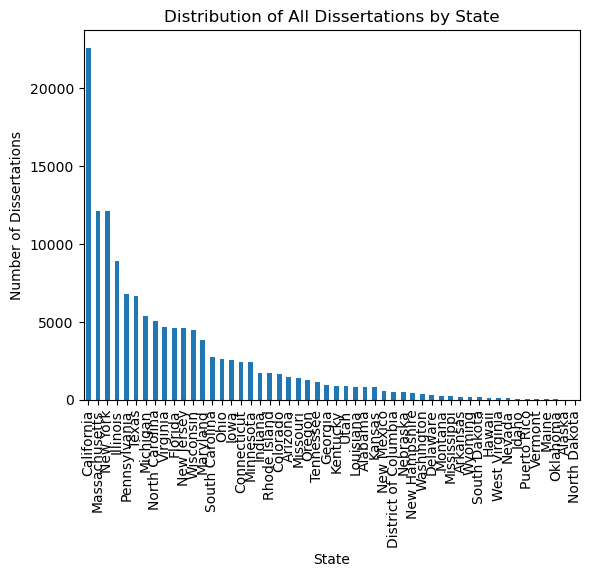

state
Alabama                   837
Alaska                      9
Arizona                  1446
Arkansas                  178
California              22600
Colorado                 1643
Connecticut              2452
Delaware                  331
District of Columbia      494
Florida                  4630
Georgia                   930
Hawaii                    116
Idaho                      73
Illinois                 8894
Indiana                  1728
Iowa                     2545
Kansas                    828
Kentucky                  905
Louisiana                 844
Maine                      44
Maryland                 3861
Massachusetts           12142
Michigan                 5347
Minnesota                2432
Mississippi               241
Missouri                 1418
Montana                   250
Nebraska                  493
Nevada                     91
New Hampshire             404
New Jersey               4610
New Mexico                574
New York                12126
Nort

In [519]:
#dictionary to look up subject names by code
# subject_lookup = (
#     df[['subject_code', 'subject_name']]
#     .dropna()
#     .drop_duplicates(subset='subject_code')
#     .set_index('subject_code')['subject_name']
#     .to_dict()
# )

# subject_name = subject_lookup.get(subject, f"Subject {subject}")


#make a histogram of the state columns
df['state'].value_counts().plot(kind='bar')
plt.title('Distribution of All Dissertations by State')
plt.xlabel('State')
plt.ylabel('Number of Dissertations')
plt.show()

#Note some (but not all) of this imbalance may be an artifact of the data entry, rather than the prevalence of schools in each state


# list the number of names from each state
name_counts = df.groupby('state').size()
print(name_counts)

#list as ratio
ratio = name_counts/name_counts.sum()
print(ratio)

#order the states by the number of names
ordered_name_counts = name_counts.sort_values(ascending=False)
print(ordered_name_counts)



In [520]:
#Observe that some states do not have any dissertations in certain subjects. This is important to note, as it may affect the analysis of the data.

table = pd.crosstab(df["state"], df["subject"])

print(table.shape)
print((table == 0).sum().sum())      # number of zero cells
print(table.size)                    # total cells


#Also, some subjects have many more dissertations than others.
subject_counts = df["subject"].value_counts()

print(subject_counts)

#Some states have very few dissertations
print(df["state"].value_counts())

(51, 63)
1154
3213
subject
91—Game theory, economics, social and behavioral sciences    15653
68—Computer science                                          13902
62—Statistics                                                 9928
90—Operations research, mathematical programming              2771
94—Information and communication, circuits                    2753
92—Biology and other natural sciences                         2234
65—Numerical analysis                                         2071
60—Probability theory and stochastic processes                1860
76—Fluid mechanics                                            1782
93—Systems theory; control                                    1701
81—Quantum Theory                                             1609
11—Number theory                                              1596
05—Combinatorics                                              1582
97—Mathematics education                                      1560
35—Partial differential equations  

In [521]:
# #In df find the number of entries per year
# #x=df.groupby('year').size()

# #for year, count in x.items():
# #    print(f"Year {year}: {count} entries")

# #in 1929 is first year with 100 entries

# #omit all years before 1929
# df_filtered = df[df['year'] >= 1929]

In [522]:
# #pie chart for each state showing how popular subjects are


# #want to group together all subjects that are less than 3% of the total for each state into an "Other" category


# # def group_small_categories(series, threshold=0.04):
# #     """
# #     Groups categories representing less than `threshold`
# #     of the total into a single 'Other' category.
# #     """
# #     proportions = series / series.sum()
# #     small = proportions < threshold

# #     return pd.concat([
# #         series[~small],
# #         pd.Series({"Other": series[small].sum()})
# #     ])


# # counts = df["subject_name"].value_counts()

# # counts = group_small_categories(counts, threshold=0.04)

# # plt.pie(
# #     counts,
# #     labels=counts.index,
# #     autopct="%1.1f%%",
# #     startangle=90
# # )
# # plt.show()

# # for state in df['state'].unique():
# #     state_df = df[df['state'] == state]
# #     subjectcounts = state_df['subject_code'].value_counts()
# #     plt.figure(figsize=(10, 8))
# #     plt.pie(state_df['subject_code'].value_counts(), labels=state_df['subject_code'].value_counts().index, autopct='%1.1f%%')
# #     plt.title(f"Subject Popularity in {state}")
# #     plt.show()


# import matplotlib.pyplot as plt
# import pandas as pd

# threshold = 0.04  # 3%

# for state in sorted(df["state"].dropna().unique()):

#     # Data for one state
#     state_df = df[df["state"] == state]

#     # Count subjects
#     counts = state_df["subject_name"].value_counts()

#     # Compute proportions
#     proportions = counts / counts.sum()

#     # Group small categories
#     grouped_counts = pd.concat([
#         counts[proportions >= threshold],
#         pd.Series({"Other": counts[proportions < threshold].sum()})
#     ])

#     # Remove "Other" if nothing was grouped
#     grouped_counts = grouped_counts[grouped_counts > 0]

#     # Plot
#     plt.figure(figsize=(8,8))

#     plt.pie(
#         grouped_counts,
#         labels=grouped_counts.index,
#         autopct="%1.1f%%",
#         startangle=90
#     )

#     plt.title(f"Subject Distribution in {state}")

#     plt.tight_layout()
#     plt.show()

    

In [569]:
# Count dissertations by state/year/subject
counts = (
    df.groupby(['state', 'year', 'subject'])
      .size()
      .reset_index(name='count')
)

# Total dissertations per state/year
totals = (
    counts.groupby(['state', 'year'])['count']
          .sum()
          .reset_index(name='total')
)

counts = counts.merge(totals, on=['state', 'year'])

counts['proportion'] = counts['count'] / counts['total']

#print(counts)



In [524]:
#pie chart for each subject showing how popular each state is
# for subject in df['subject_code'].unique():
#     subject_df = df[df['subject_code'] == subject]
#     statecounts = subject_df['state'].value_counts()
#     plt.figure(figsize=(10, 8))
#     plt.pie(subject_df['state'].value_counts(), labels=subject_df['state'].value_counts().index, autopct='%1.1f%%')
#     plt.title(f"State Popularity for Subject {subject}")
#     plt.show()

In [525]:
#Create a histogram for each state showing how popular subjects are
#for state in df['state'].unique():
    # plt.figure(figsize=(10, 6))
    # df[df['state'] == state].groupby('subject_code').size().plot(kind='bar')
    # plt.title(f'Popularity of Subjects in {state}')
    # plt.xlabel('Subject')
    # plt.ylabel('Count')
    # plt.show()


In [526]:
#histogram chart for each subject showing how popular each state is
# for subject in df['subject_code'].unique():
#     plt.figure(figsize=(10, 6))
#     df[df['subject_code'] == subject].groupby('state').size().plot(kind='bar')
#     plt.title(f'Popularity of {subject} by State')
#     plt.xlabel('State')
#     plt.ylabel('Count')
#     plt.show()

In [527]:
#remove rows prior to 1950, due to sparsity of the original data, and the fact that the model is not well trained on those years
df2 = df[df['year'] >= 1950].copy()



subject = 11

# Only years >= 1950
df2 = df[df['year'] >= 1950].copy()


#grouping by decade, rather than year, to reduce noise and make the data more interpretable
df2['decade'] = (df2['year'] // 10) * 10

totals = (
    df2.groupby(['decade', 'state'])
       .size()
       .rename('total')
       .reset_index()
)

subject_counts = (
    df2[df2['subject'] == subject]
       .groupby(['decade', 'state'])
       .size()
       .rename('count')
       .reset_index()
)

prop = totals.merge(
    subject_counts,
    on=['decade', 'state'],
    how='left'
)

prop['count'] = prop['count'].fillna(0)
prop['prop'] = prop['count'] / prop['total']


# Determine which state has the highest proportion of subject for each decade. 
# Note that this is not necessarily the state with the highest number of dissertations in that subject, but rather the state where that subject is most popular relative to other subjects. 
# So if a state only had one dissertation, it would likely be the winner. This applies to the university of Vermont, the only mathematics PhD-granting institution in Vermont. 

winner = (
    prop.loc[prop.groupby('decade')['prop'].idxmax()]
        .sort_values('decade')
)

print(winner)



     decade    state  total  count  prop
0    1950.0  Alabama      6    0.0   0.0
35   1960.0  Alabama     65    0.0   0.0
77   1970.0  Alabama    102    0.0   0.0
123  1980.0  Alabama     50    0.0   0.0
169  1990.0  Alabama    141    0.0   0.0
219  2000.0  Alabama    172    0.0   0.0
270  2010.0  Alabama    215    0.0   0.0
321  2020.0  Alabama     84    0.0   0.0


3. Modeling. We begin by considering a multinomial logistic regression to model the data, with features as years and states, and targets as subject codes. 

In [528]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# -----------------------
# Prepare the data
# -----------------------

model_df = df[["state", "year", "subject"]].copy()

model_df = model_df.dropna()

model_df["state"] = model_df["state"].astype("category")
model_df["year"] = model_df["year"].astype(int)
model_df["subject"] = model_df["subject"].astype("category")

X = model_df[["year", "state"]]
y = model_df["subject"]

# -----------------------
# Train/test split
# -----------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# -----------------------
# Preprocessing
# -----------------------

preprocessor = ColumnTransformer(
    transformers=[
        ("state",
         OneHotEncoder(handle_unknown="ignore"),
         ["state"]),

        ("year",
         StandardScaler(),
         ["year"])
    ]
)

# -----------------------
# Multinomial logistic regression
# -----------------------

model = Pipeline([
    ("preprocess", preprocessor),

    ("clf",
     LogisticRegression(
         solver="lbfgs",
         max_iter=5000,
         random_state=42
     ))
])

# -----------------------
# Fit model
# -----------------------

model.fit(X_train, y_train)

# -----------------------
# Evaluate
# -----------------------

y_pred = model.predict(X_test)

print("Training accuracy:",
      model.score(X_train, y_train))

print("Test accuracy:",
      model.score(X_test, y_test))

print(classification_report(y_test, y_pred))

# -----------------------
# Refit on the FULL dataset
# (recommended before making figures)
# -----------------------

model.fit(X, y)

Training accuracy: 0.2569683806286101
Test accuracy: 0.256657223796034
                                                           precision    recall  f1-score   support

                                               00—General       0.00      0.00      0.00        93
                                 01—History and biography       0.00      0.00      0.00        35
                    03—Mathematical logic and foundations       0.00      0.00      0.00       215
                                         05—Combinatorics       0.23      0.04      0.07       316
         06—Order, lattices, ordered algebraic structures       0.00      0.00      0.00        19
                             08—General algebraic systems       0.00      0.00      0.00        11
                                         11—Number theory       0.00      0.00      0.00       319
                          12—Field theory and polynomials       0.00      0.00      0.00         9
                        13—Commutativ

/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('state', ...), ('year', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers con

In [529]:
#doing cross validation to get a better estimate of the multinomial model's performance

from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# Evaluating the model using cross-validation with two different scoring metrics: negative log loss and accuracy.
scores1 = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring="neg_log_loss"
)

scores2 = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print(-scores1.mean())
print(scores2.mean())




2.8432723289335446
0.2559618447150719


Note that a model which assigned equal probability to each of the roughly 60 subjects would have a log loss of log(60), about 4.1, and an accuracy of about 0.02. The model's performance is significantly better than this baseline, indicating that it is able to learn meaningful patterns from the data.

In [530]:
#this gives the probabilities of each subject code, given the year and state

probs = model.predict_proba(X)

classes = model.named_steps["clf"].classes_

probs_df = pd.DataFrame(probs, columns=classes)

probs_df.head()

,00—General,01—History and biography,03—Mathematical logic and foundations,05—Combinatorics,"06—Order, lattices, ordered algebraic structures",08—General algebraic systems,11—Number theory,12—Field theory and polynomials,13—Commutative rings and algebras,14—Algebraic geometry,...,"82—Statistical mechanics, structure of matter",83—Relativity and gravitational theory,85—Astronomy and astrophysics,86—Geophysics,"90—Operations research, mathematical programming","91—Game theory, economics, social and behavioral sciences",92—Biology and other natural sciences,93—Systems theory; control,"94—Information and communication, circuits",97—Mathematics education
0,0.000665,0.024961,0.014680,0.000685,0.008253,0.004894,0.000169,0.000256,0.000554,0.000024,...,0.059112,0.001218,0.008209,0.010424,0.037289,0.336974,0.018327,0.015457,0.009391,0.035794
1,0.000717,0.022497,0.015198,0.000836,0.008102,0.004999,0.000205,0.000273,0.000654,0.000030,...,0.056740,0.001250,0.008084,0.010354,0.039109,0.337338,0.019562,0.015966,0.010035,0.036482
2,0.001212,0.007991,0.017937,0.004133,0.006041,0.005260,0.000928,0.000409,0.002421,0.000171,...,0.034780,0.001368,0.006184,0.008533,0.051673,0.297679,0.030095,0.018483,0.015593,0.037615
3,0.001212,0.007991,0.017937,0.004133,0.006041,0.005260,0.000928,0.000409,0.002421,0.000171,...,0.034780,0.001368,0.006184,0.008533,0.051673,0.297679,0.030095,0.018483,0.015593,0.037615
4,0.001337,0.005795,0.017971,0.006089,0.005348,0.005110,0.001336,0.000437,0.003300,0.000261,...,0.029210,0.001342,0.005513,0.007761,0.053367,0.275776,0.032382,0.018421,0.016823,0.036338


In [531]:
#predicted probabilities for each subject code for California in 2025

future = pd.DataFrame({
    "state": ["California"],   # or whatever format your state column uses
    "year": [2025]
})

p = model.predict_proba(future)

pd.Series(
    p[0],
    index=model.named_steps["clf"].classes_
).sort_values(ascending=False)

68—Computer science                                          0.237833
62—Statistics                                                0.121870
91—Game theory, economics, social and behavioral sciences    0.110034
94—Information and communication, circuits                   0.051877
65—Numerical analysis                                        0.036841
60—Probability theory and stochastic processes               0.033872
92—Biology and other natural sciences                        0.030956
11—Number theory                                             0.030796
14—Algebraic geometry                                        0.029659
05—Combinatorics                                             0.028070
35—Partial differential equations                            0.026725
90—Operations research, mathematical programming             0.026214
76—Fluid mechanics                                           0.025345
53—Differential geometry                                     0.025312
93—Systems theory; c

In [532]:
# removing some of the early years which had sparser data. 
years = range(1950, 2031)

future = pd.DataFrame([
    (state, year)
    for state in model_df["state"].unique()
    for year in years
], columns=["state", "year"])

probs = model.predict_proba(future[["state", "year"]])

result = pd.concat(
    [future.reset_index(drop=True),
     pd.DataFrame(probs, columns=model.named_steps["clf"].classes_)],
    axis=1
)

We will make a some visualization of the geography here, which is based on our predictive model.

In [533]:
#building prediction grid

years = range(1950, 2031)
states = model_df["state"].unique()

future = pd.DataFrame([
    (state, year)
    for state in states
    for year in years
], columns=["state", "year"])

probs = model.predict_proba(future[["state", "year"]])


probs_df = pd.DataFrame(
    probs,
    columns=model.named_steps["clf"].classes_
)

result = pd.concat([future.reset_index(drop=True), probs_df], axis=1)

In [534]:
#reduce to top subjects

top_subjects = (
    model_df["subject"]
    .value_counts()
    .head(10)
    .index
)

anim_df = result.melt(
    id_vars=["state", "year"],
    value_vars=top_subjects,
    var_name="subject",
    value_name="prob"
)

In [535]:
probs = model.predict_proba(future[["state", "year"]])

classes = model.named_steps["clf"].classes_

probs_df = pd.DataFrame(probs, columns=classes)

result = future.reset_index(drop=True).copy()
result = pd.concat([result, probs_df.reset_index(drop=True)], axis=1)

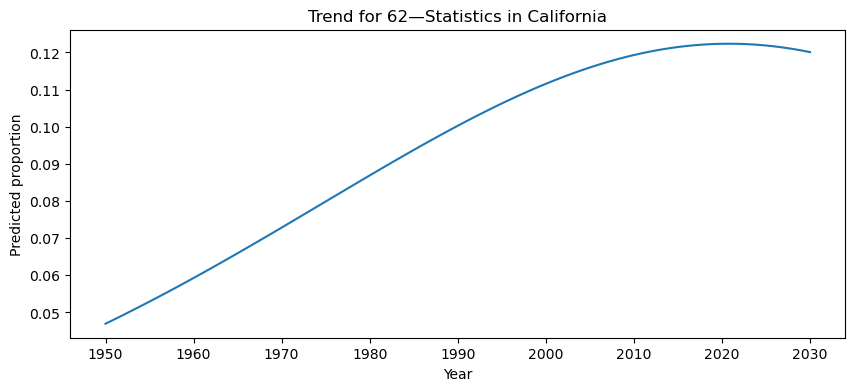

In [536]:
 

subject = "62\u2014Statistics"


# subject_lookup = (
#     df[['subject_code', 'subject_name']]
#     .dropna()
#     .drop_duplicates(subset='subject_code')
#     .set_index('subject_code')['subject_name']
#     .to_dict()
# )


#subject_name = subject_lookup.get(subject, f"Subject {subject}")


import seaborn as sns
import matplotlib.pyplot as plt

state = "California"

df_hm = result[result["state"] == state]

pivot = df_hm.pivot(index="year", columns="state", values=subject)

plt.figure(figsize=(10,4))
plt.plot(df_hm["year"], df_hm[subject])
plt.title(f"Trend for {subject} in {state}")
plt.ylabel("Predicted proportion")
plt.xlabel("Year")
plt.show()



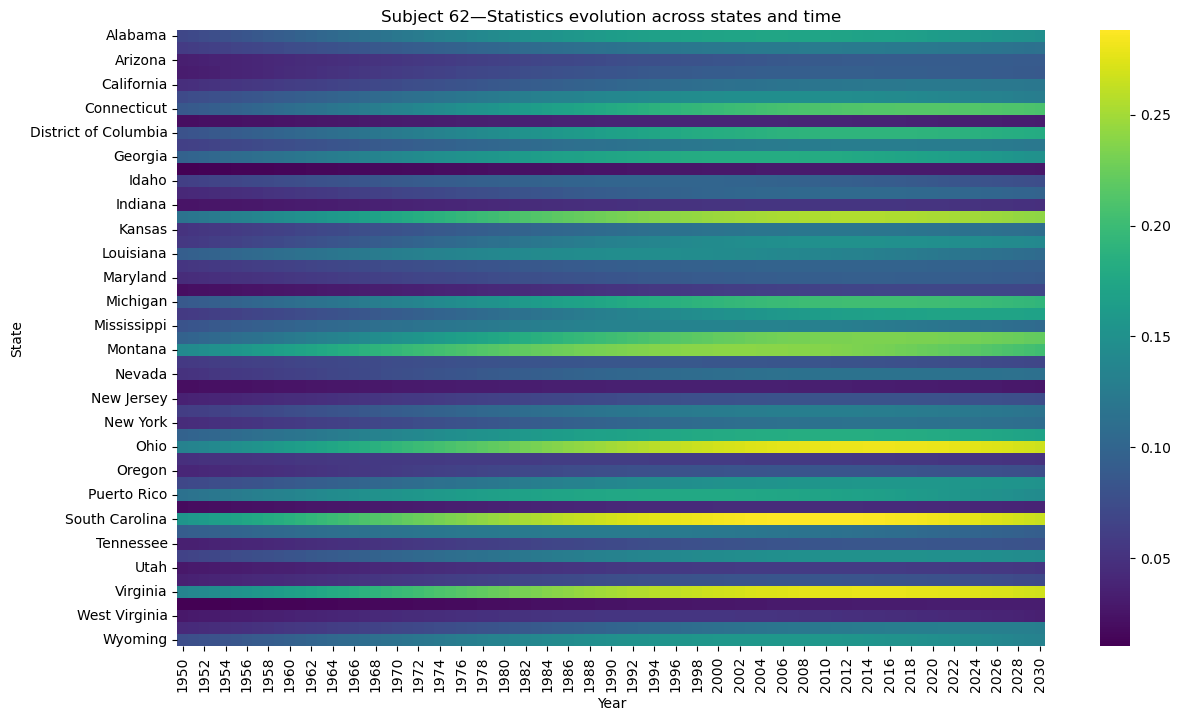

In [537]:

#heat map with states listed alphabetically
pivot = result.pivot_table(
    index="state",
    columns="year",
    values=subject
)

plt.figure(figsize=(14,8))
sns.heatmap(pivot, cmap="viridis")
plt.title(f"Subject {subject} evolution across states and time")
plt.xlabel("Year")
plt.ylabel("State")
plt.show()

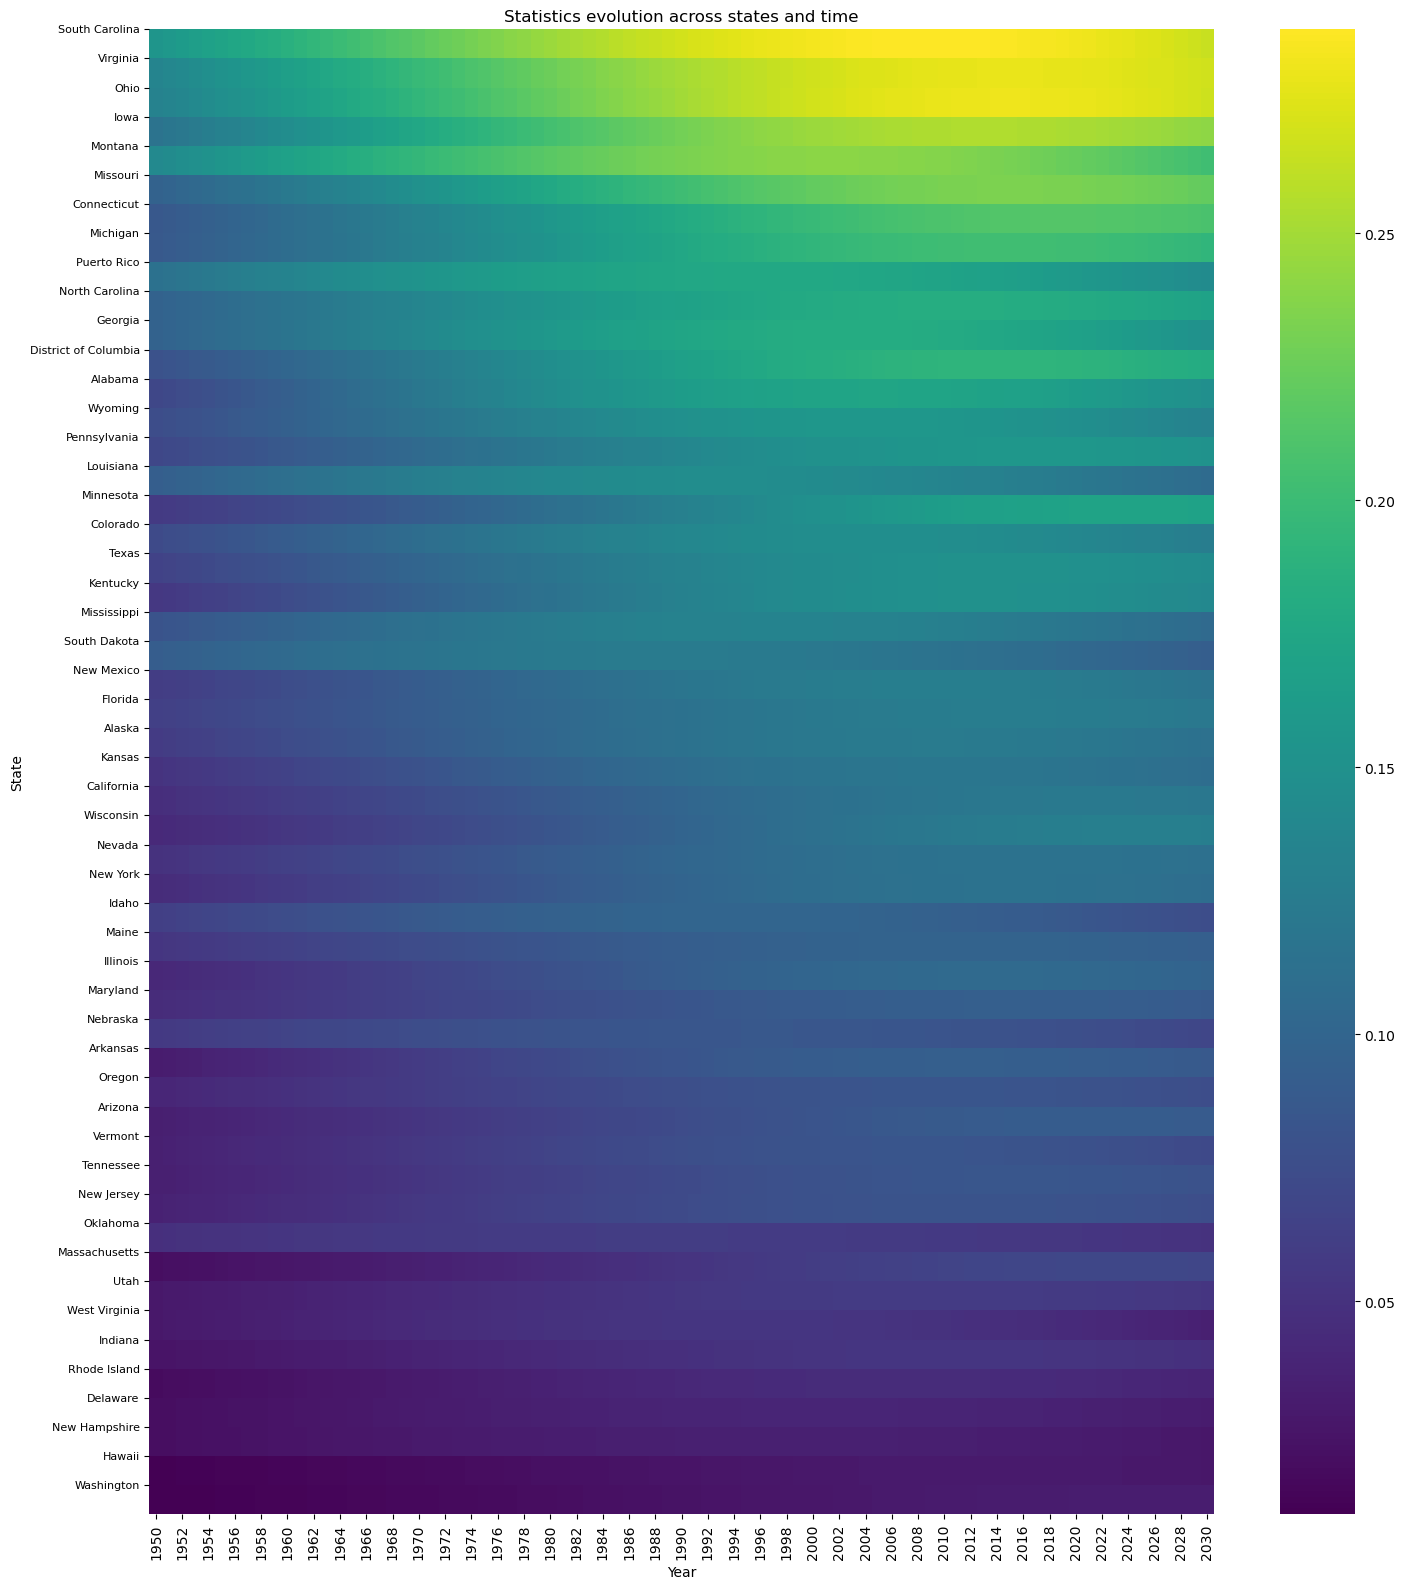

In [538]:
#heat map with naems listed in order of brightness

plt.figure(figsize=(15, 16))

pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

ax = sns.heatmap(pivot, cmap="viridis")

ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=8)

plt.title(f"{subject_name} evolution across states and time")
plt.xlabel("Year")
plt.ylabel("State")

plt.tight_layout()
plt.show()

   decade         state  count
0  1950.0       Georgia      2
1  1960.0  Pennsylvania      6
2  1970.0      Maryland     11
3  1980.0      Maryland     10
4  1990.0    New Jersey     13


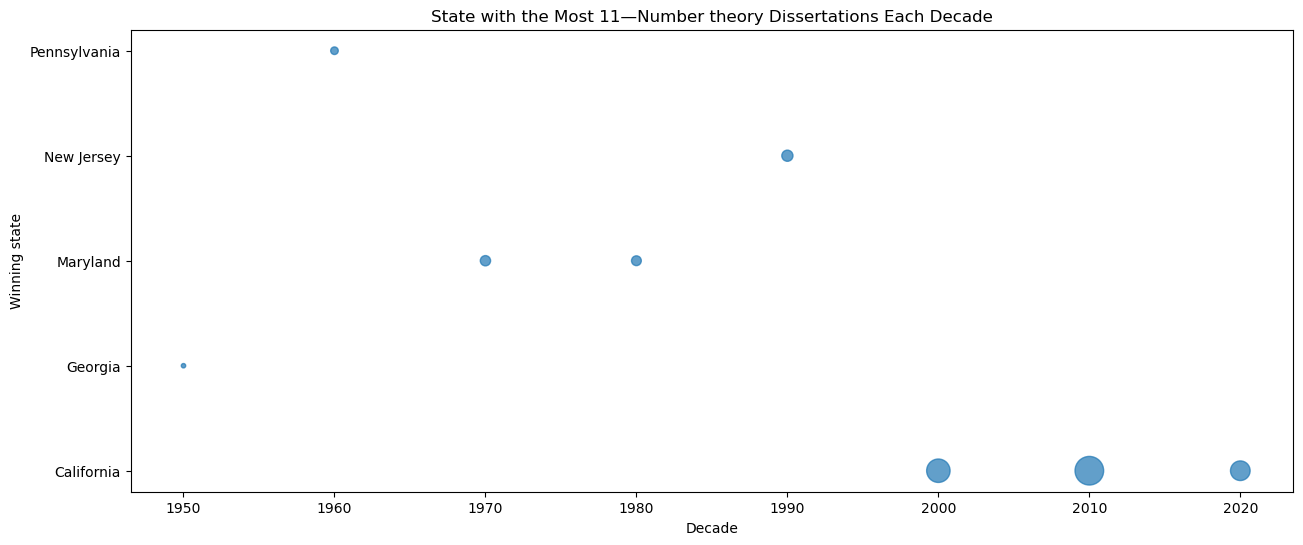

In [539]:
#repeat the analysis but with the most popular subject being counted by the total number, rather than proportion.

subject = "11\u2014Number theory"

# Only years >= 1950
df2 = df[df['year'] >= 1950].copy()

df2['decade'] = (df2['year'] // 10) * 10

counts = (
    df2[df2['subject'] == subject]
      .groupby(['decade', 'state'])
      .size()
      .rename('count')
      .reset_index()
)

winner = (
    counts.loc[counts.groupby('decade')['count'].idxmax()]
          .sort_values('decade')
          .reset_index(drop=True)
)

print(winner.head())


states = sorted(winner['state'].unique())
state_to_num = {s: i for i, s in enumerate(states)}

winner['y'] = winner['state'].map(state_to_num)

plt.figure(figsize=(15,6))

plt.scatter(
    winner['decade'],
    winner['y'],
    s=winner['count'] * 5,   # adjust multiplier
    alpha=0.7
)

plt.yticks(range(len(states)), states)
plt.xlabel("Decade")
plt.ylabel("Winning state")
plt.title(f"State with the Most {subject} Dissertations Each Decade")

plt.show()



<Figure size 1400x700 with 0 Axes>

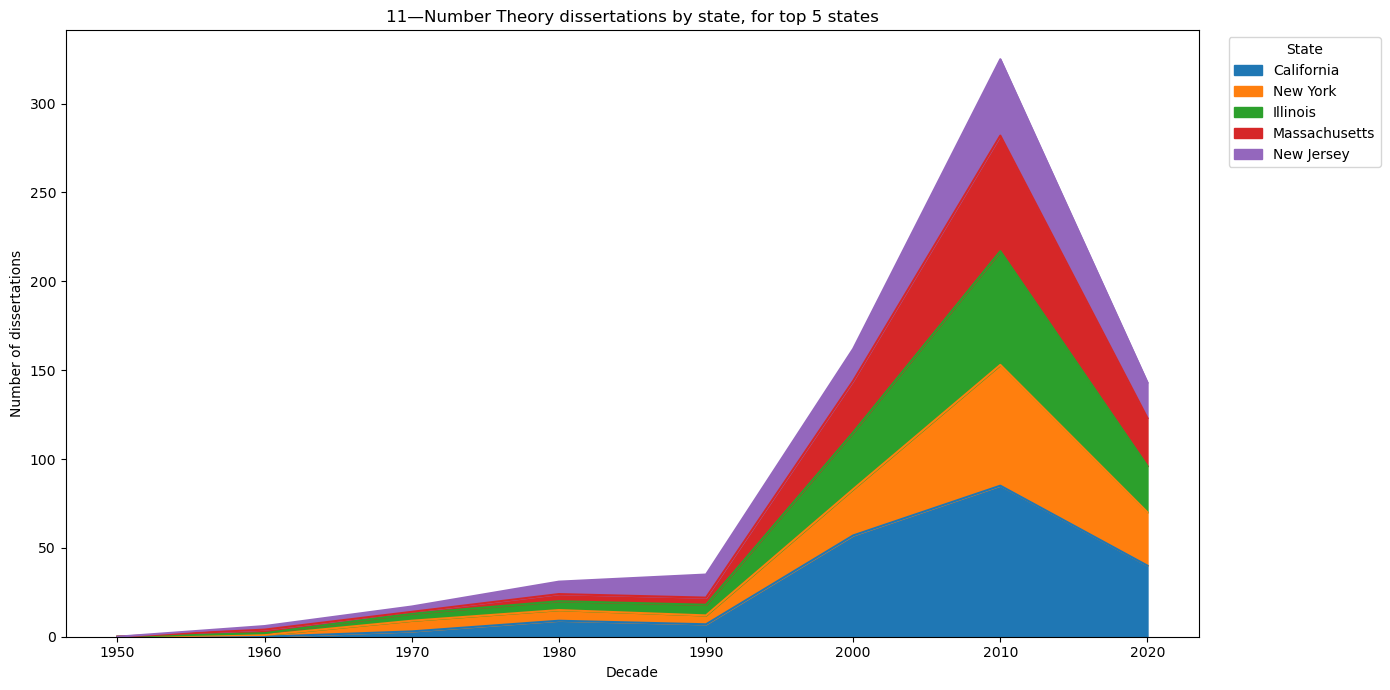

(1592, 7)
                       name                             school    year  \
1318     Joseph Lewis Yucas  The Pennsylvania State University  1978.0   
1904       Edward M. Corwin                  Lehigh University  1977.0   
1950    Roland B. di Franco                 Indiana University  1965.0   
2234           Donggyun Kim             The University of Iowa  1992.0   
3074  Robert Henry Cranford         Louisiana State University  1964.0   

               subject                       school_clean         state  \
1318  11—Number theory  THE PENNSYLVANIA STATE UNIVERSITY  Pennsylvania   
1904  11—Number theory                  LEHIGH UNIVERSITY  Pennsylvania   
1950  11—Number theory                 INDIANA UNIVERSITY       Indiana   
2234  11—Number theory             THE UNIVERSITY OF IOWA          Iowa   
3074  11—Number theory         LOUISIANA STATE UNIVERSITY     Louisiana   

      decade  
1318  1970.0  
1904  1970.0  
1950  1960.0  
2234  1990.0  
3074  1960.0  


In [540]:
subject = "11\u2014Number Theory"

# Only years >= 1950
df2 = df[df['year'] >= 1950].copy()

# Keep only dissertations in the subject
tmp = df2[df2['subject'].str.startswith("11", na=False)].copy()


# Create decade
tmp['decade'] = (tmp['year'] // 10) * 10

counts = (
    tmp.groupby(['decade', 'state'])
       .size()
       .unstack(fill_value=0)
)

top_states = (
    counts.sum(axis=0)
          .nlargest(5)
          .index
)

counts = counts[top_states]



plt.figure(figsize=(14,7))

counts.plot.area(figsize=(14,7))

plt.title(f"{subject} dissertations by state, for top 5 states")
plt.xlabel("Decade")
plt.ylabel("Number of dissertations")
plt.legend(title="State", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

print(tmp.shape)
print(tmp.head())

In [541]:
states = sorted(model_df["state"].unique())
years = range(1950, 2026)   

future = pd.MultiIndex.from_product(
    [states, years],
    names=["state", "year"]
).to_frame(index=False)

probs = model.predict_proba(future)

prob_df = pd.DataFrame(
    probs,
    columns=model.named_steps["clf"].classes_
)

result = pd.concat(
    [future.reset_index(drop=True), prob_df],
    axis=1
)

print(result)

                     state  year  00—General  01—History and biography  \
0                  Alabama  1950    0.004044                  0.011200   
1                  Alabama  1951    0.004162                  0.010853   
2                  Alabama  1952    0.004280                  0.010512   
3                  Alabama  1953    0.004399                  0.010175   
4                  Alabama  1954    0.004519                  0.009844   
5                  Alabama  1955    0.004639                  0.009518   
6                  Alabama  1956    0.004760                  0.009197   
7                  Alabama  1957    0.004881                  0.008882   
8                  Alabama  1958    0.005002                  0.008573   
9                  Alabama  1959    0.005123                  0.008269   
10                 Alabama  1960    0.005244                  0.007972   
11                 Alabama  1961    0.005364                  0.007680   
12                 Alabama  1962    0.

In [542]:

#Determines change in the predicted probability of subject over time, from the first year to the last year in the dataset

subject = "62\u2014Statistics"



pivot = result.pivot(
    index="year",
    columns="state",
    values=subject
)

increase = (
    pivot.loc[pivot.index.max()] -
    pivot.loc[pivot.index.min()]
)

increase.sort_values(ascending=False)

increase.sort_values(ascending=False).head(10)

state
Ohio                    0.142182
Virginia                0.138469
Iowa                    0.131405
Missouri                0.131272
Connecticut             0.126275
South Carolina          0.119727
Minnesota               0.114962
Michigan                0.111244
District of Columbia    0.105454
Kentucky                0.089375
dtype: float64

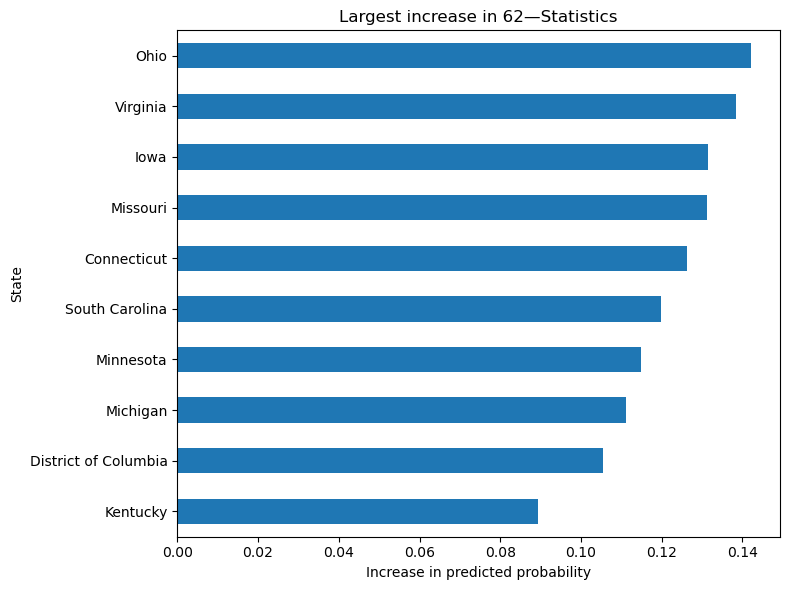

In [543]:
#plot the largest increase in predicted probability for the subject across states, from the first year to the last year in the dataset

top10 = increase.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,6))

top10.sort_values().plot.barh()

plt.xlabel("Increase in predicted probability")
plt.ylabel("State")
plt.title(f"Largest increase in {subject}")

plt.tight_layout()
plt.show()

In [544]:
##Determines change in the predicted probability of subject over time, using all the years in the dataset, rather than just the first and last year, by calculating the slope of the linear regression line for each state


from scipy.stats import linregress

subject = "62\u2014Statistics"


pivot = result.pivot(
    index="year",
    columns="state",
    values=subject
)

slopes = {}

for state in pivot.columns:
    slope, intercept, r, p, stderr = linregress(
        pivot.index,
        pivot[state]
    )
    slopes[state] = slope

slopes = pd.Series(slopes).sort_values(ascending=False)

print(slopes.head(10))

Ohio                    0.002112
Virginia                0.002015
Missouri                0.001978
Iowa                    0.001944
Connecticut             0.001867
South Carolina          0.001773
Minnesota               0.001708
Michigan                0.001687
District of Columbia    0.001607
Kentucky                0.001343
dtype: float64


In [545]:
#determine how subjects changed in their predicted probabilities in a given state, just comparing the first and last year in the dataset, rather than using all the years in the dataset

state = "California"   

state_df = result[result["state"] == state]

first_year = state_df["year"].min()
last_year = state_df["year"].max()

first = state_df[state_df["year"] == first_year].iloc[0]
last = state_df[state_df["year"] == last_year].iloc[0]

# Subject columns are everything except state and year
subject_cols = [c for c in result.columns if c not in ["state", "year"]]

change = last[subject_cols] - first[subject_cols]

change = (
    change.rename_axis("subject")
          .reset_index(name="change")
)


change.sort_values("change", ascending=False)

,subject,change
46,68—Computer science,0.174978
44,62—Statistics,0.074913
45,65—Numerical analysis,0.03462
6,11—Number theory,0.029814
9,14—Algebraic geometry,0.029158
43,60—Probability theory and stochastic processes,0.027991
3,05—Combinatorics,0.027373
24,35—Partial differential equations,0.024772
38,53—Differential geometry,0.024528
41,57—Manifolds and cell complexes,0.022496


In [546]:
#now taking all the data into account, not just the first and last year

from scipy.stats import linregress

state = "California"   

state_df = result[result["state"] == state].sort_values("year")

# All subject columns
subject_cols = [c for c in result.columns if c not in ["state", "year"]]

slopes = []

for subject in subject_cols:

    slope, intercept, r, p, stderr = linregress(
        state_df["year"],
        state_df[subject]
    )

    slopes.append({
        "subject": subject,
        #"subject_name": subject_lookup.get(subject, "Unknown"),
        "slope": slope,
        "p_value": p,
        "r_squared": r**2
    })

slopes = pd.DataFrame(slopes)

slopes.sort_values("slope", ascending=False).head(10)

slopes["abs_slope"] = slopes["slope"].abs()


#showing which subjects had the largest absolute change in predicted probability over time, regardless of whether it was an increase or decrease
slopes.sort_values("abs_slope", ascending=False).head(10)

,subject,slope,p_value,r_squared,abs_slope
58,"91—Game theory, economics, social and behavior...",-0.003983,2.558071e-89,0.995699,0.003983
46,68—Computer science,0.002542,3.402856e-88,0.995388,0.002542
44,62—Statistics,0.001110,2.355316e-58,0.970470,0.001110
50,"78—Optics, electromagnetic theory",-0.000704,2.901033e-48,0.944687,0.000704
52,81—Quantum Theory,-0.000652,2.345506e-102,0.998089,0.000652
45,65—Numerical analysis,0.000456,1.038536e-47,0.942749,0.000456
43,60—Probability theory and stochastic processes,0.000397,1.920336e-83,0.993801,0.000397
53,"82—Statistical mechanics, structure of matter",-0.000392,8.554881e-59,0.971267,0.000392
6,11—Number theory,0.000373,1.373742e-38,0.899065,0.000373
9,14—Algebraic geometry,0.000345,1.853367e-32,0.852288,0.000345


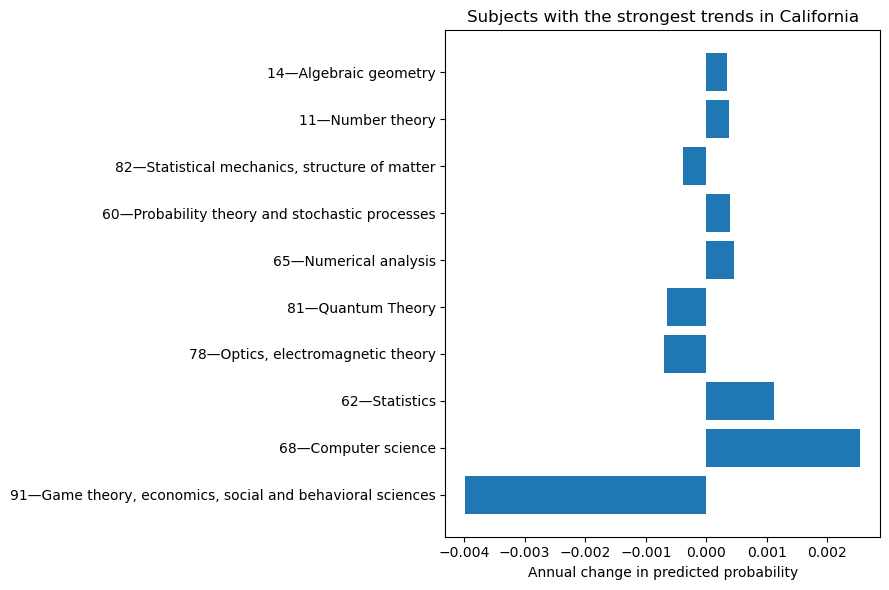

In [547]:
top10 = (
    slopes
    .sort_values("abs_slope", ascending=False)
    .head(10)
)

plt.figure(figsize=(9,6))

plt.barh(top10["subject"], top10["slope"])

plt.xlabel("Annual change in predicted probability")
plt.title(f"Subjects with the strongest trends in {state}")

plt.tight_layout()
plt.show()

In [548]:
# Here volatility is defined as the standard deviation of the predicted probabilities for each subject over time, for each state. This gives a measure of how much the predicted probabilities fluctuate over time. 
# Here we are considering the question of which states experienced lots of changes across many subjects. 

subject_cols = [c for c in result.columns if c not in ["state", "year"]]

volatility = []

for state in result["state"].unique():

    state_df = result[result["state"] == state]

    stds = state_df[subject_cols].std()

    volatility.append({
        "state": state,
        "average_volatility": stds.mean(),
        "maximum_volatility": stds.max(),
        "most_volatile_subject": stds.idxmax()
    })

volatility = pd.DataFrame(volatility)


volatility.sort_values("average_volatility", ascending=False)

,state,average_volatility,maximum_volatility,most_volatile_subject
48,West Virginia,0.007345,0.157387,05—Combinatorics
0,Alabama,0.006875,0.102591,54—General topology
3,Arkansas,0.006875,0.143526,54—General topology
39,Rhode Island,0.006724,0.137654,"91—Game theory, economics, social and behavior..."
45,Vermont,0.006529,0.128224,"91—Game theory, economics, social and behavior..."
50,Wyoming,0.006524,0.106172,"91—Game theory, economics, social and behavior..."
17,Kentucky,0.006400,0.052883,"40—Sequences, series, summability"
7,Delaware,0.006384,0.056395,65—Numerical analysis
16,Kansas,0.006344,0.130781,"91—Game theory, economics, social and behavior..."
10,Georgia,0.006153,0.093386,97—Mathematics education


In [549]:
# Now we consider which state had one subject that changed dramatically. Volatility is now year to year change. Note volatility in this sense is quite low. 

state_df[subject_cols].diff().abs()

volatility = []

for state in result["state"].unique():

    state_df = (
        result[result["state"] == state]
        .sort_values("year")
    )

    annual_change = (
        state_df[subject_cols]
        .diff()
        .abs()
        .mean()
        .mean()
    )

    volatility.append({
        "state": state,
        "volatility": annual_change
    })

volatility = pd.DataFrame(volatility)

volatility.sort_values("volatility", ascending=False)

,state,volatility
48,West Virginia,0.000323
0,Alabama,0.000310
3,Arkansas,0.000307
39,Rhode Island,0.000292
7,Delaware,0.000288
45,Vermont,0.000287
50,Wyoming,0.000287
17,Kentucky,0.000283
18,Louisiana,0.000281
12,Idaho,0.000278


In [550]:
# Here we consider how states changed the distribution of their subjects. 
import numpy as np


subject_cols = [c for c in result.columns if c not in ["state", "year"]]



volatility = []

for state in result["state"].unique():

    state_df = (
        result[result["state"] == state]
        .sort_values("year")
    )

    probs = state_df[subject_cols].to_numpy()

    # Euclidean distance between consecutive years
    distances = np.sqrt(((probs[1:] - probs[:-1]) ** 2).sum(axis=1))

    volatility.append({
        "state": state,
        "average_distance": distances.mean(),
        "maximum_distance": distances.max(),
        "total_distance": distances.sum()
    })

volatility = (
    pd.DataFrame(volatility)
      .sort_values("average_distance", ascending=False)
)

print(volatility.head(10))

            state  average_distance  maximum_distance  total_distance
48  West Virginia          0.007910          0.010617        0.593245
3        Arkansas          0.007479          0.011139        0.560946
23      Minnesota          0.006982          0.008417        0.523644
39   Rhode Island          0.006734          0.008405        0.505035
0         Alabama          0.006623          0.009031        0.496689
45        Vermont          0.006581          0.008329        0.493548
49      Wisconsin          0.006549          0.007966        0.491152
16         Kansas          0.006454          0.007603        0.484021
50        Wyoming          0.006247          0.007285        0.468556
47     Washington          0.006061          0.007404        0.454594


In [551]:
# Finding which subjects caused the most change in a given state. 

state = "California"

state_df = (
    result[result["state"] == state]
    .sort_values("year")
)

changes = (
    state_df[subject_cols]
    .diff()
    .abs()
    .mean()
    .sort_values(ascending=False)
)

changes = changes.rename_axis("subject_code").reset_index(name="mean_annual_change")
#changes["subject_name"] = changes["subject_code"].map(subject_lookup)

print(changes.head(10))

                                        subject_code  mean_annual_change
0  91—Game theory, economics, social and behavior...            0.003776
1                                68—Computer science            0.002333
2                                      62—Statistics            0.001012
3                  78—Optics, electromagnetic theory            0.000723
4                                  81—Quantum Theory            0.000626
5                              65—Numerical analysis            0.000462
6                                   11—Number theory            0.000398
7      82—Statistical mechanics, structure of matter            0.000391
8                              14—Algebraic geometry            0.000389
9     60—Probability theory and stochastic processes            0.000373


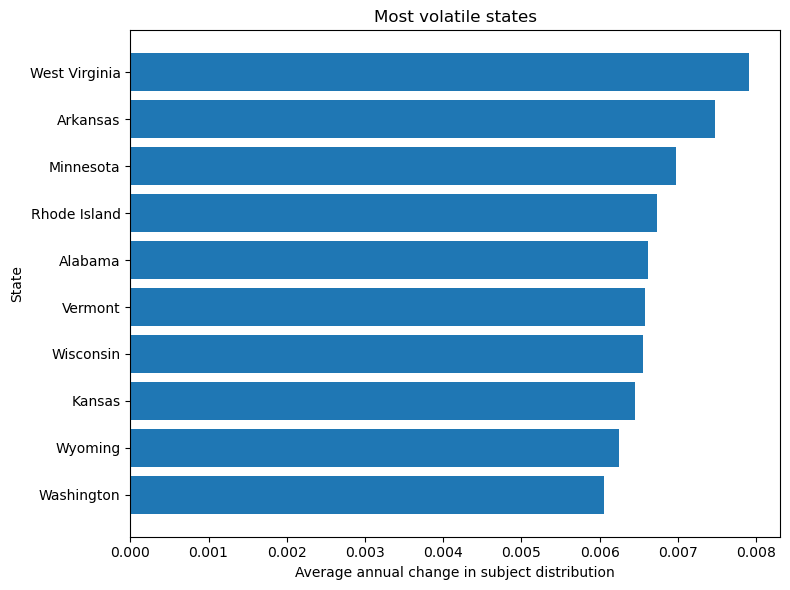

In [552]:

#graph the most volatile states, based on the average annual change in subject distribution
top10 = volatility.head(10)

plt.figure(figsize=(8,6))

plt.barh(
    top10["state"],
    top10["average_distance"]
)

plt.xlabel("Average annual change in subject distribution")
plt.ylabel("State")
plt.title("Most volatile states")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

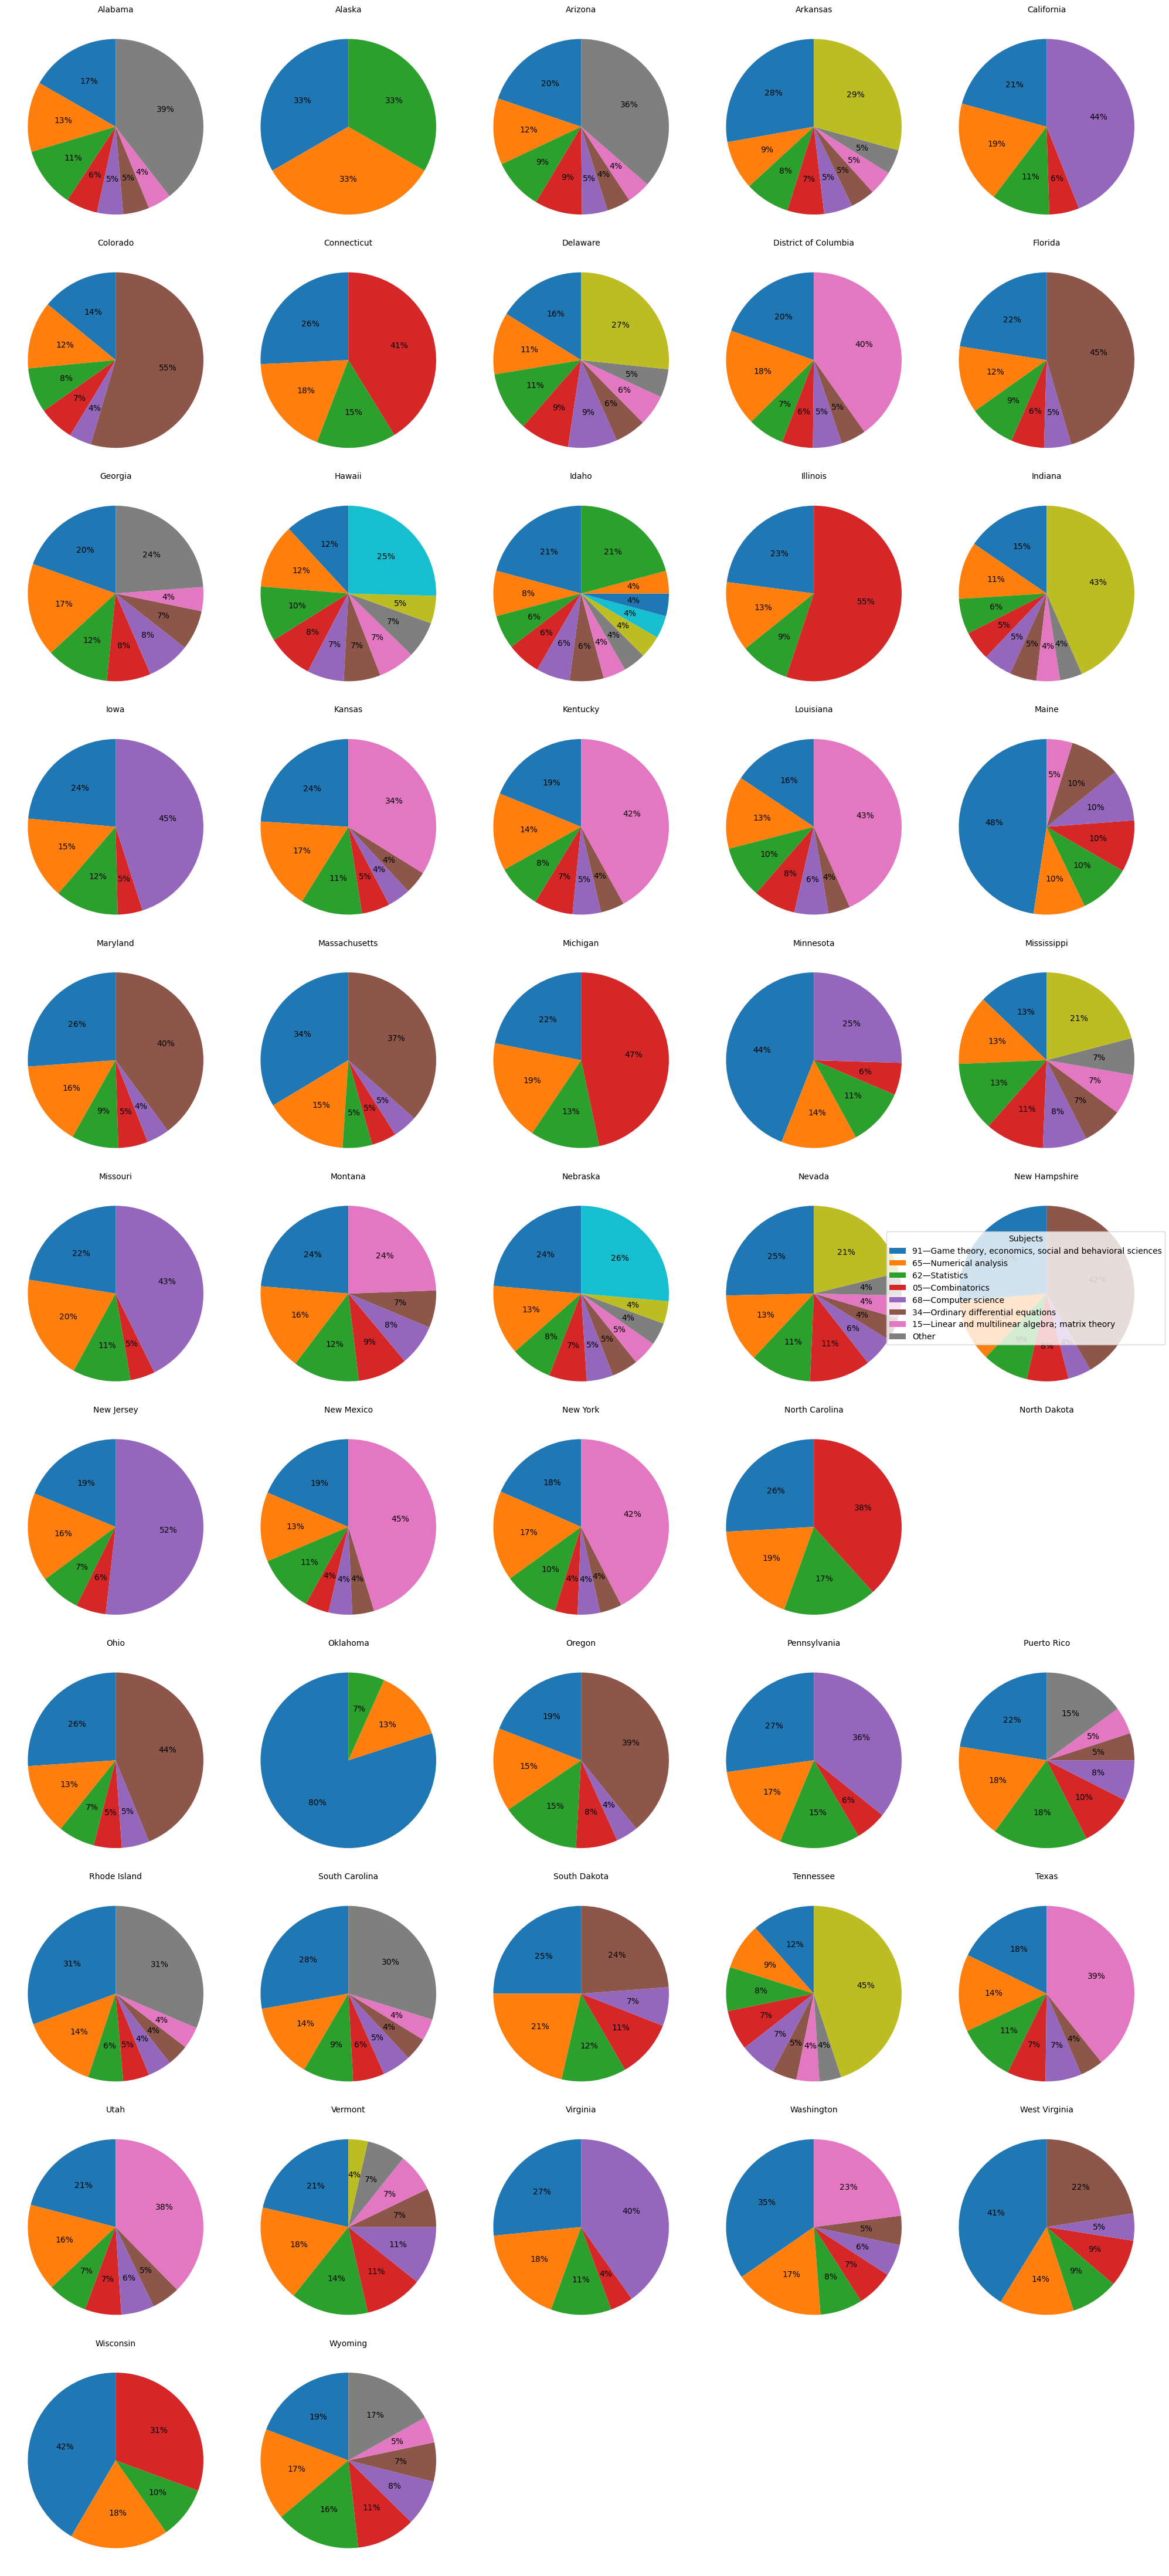

In [553]:
import math

threshold = 0.04  # Group subjects with <3% into "Other"

states = sorted(df["state"].dropna().unique())

ncols = 5
nrows = math.ceil(len(states) / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(4*ncols, 4*nrows)
)

axes = axes.flatten()

for ax, state in zip(axes, states):

    state_df = df[df["state"] == state]

    counts = state_df["subject"].value_counts()
    proportions = counts / counts.sum()

    grouped = pd.concat([
        counts[proportions >= threshold],
        pd.Series({"Other": counts[proportions < threshold].sum()})
    ])

    # Remove "Other" if empty
    grouped = grouped[grouped > 0]

    ax.pie(
        grouped,
        labels=None,          # Too crowded to label every pie
        autopct="%1.0f%%",
        startangle=90,
        #textprops={"fontsize": 7}
    )

fig.legend(
    grouped.index,
    loc="center right",
    title="Subjects"
)

plt.subplots_adjust(right=0.85)

for ax, state in zip(axes, states):
    ax.set_title(state, fontsize=10)

# Hide any unused subplots
for ax in axes[len(states):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

We also consider a modified model, multinomial regression and allowing nonlinear year-to-year probabilities. The cross validation shows slightly improved scores over the above model. 

In [554]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    PolynomialFeatures
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# -----------------------
# Prepare data
# -----------------------

model_df = df[["state", "year", "subject"]].dropna().copy()

model_df["state"] = model_df["state"].astype("category")
model_df["year"] = model_df["year"].astype(int)
#model_df["subject_code"] = model_df["subject_code"].astype(int)
model_df["subject"] = model_df["subject"].astype("category")


X = model_df[["state", "year"]]
y = model_df["subject"]

# -----------------------
# Preprocessing
# -----------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "state",
            OneHotEncoder(drop=None, handle_unknown="ignore"),
            ["state"]
        ),
        (
            "year",
            StandardScaler(),
            ["year"]
        )
    ]
)

# -----------------------
# Model
# -----------------------

model = Pipeline([
    ("preprocess", preprocessor),

    # Creates state × year interaction terms
    ("interactions",
     PolynomialFeatures(
         degree=2,
         interaction_only=True,
         include_bias=False
     )),

    ("clf",
     LogisticRegression(
         solver="lbfgs",
         max_iter=5000,
         random_state=42
     ))
])

model.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('interactions', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('state', ...), ('year', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tr

In [555]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring="neg_log_loss"
)

print("Mean log loss:", -scores.mean())

scores = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Mean accuracy:", scores.mean())

Mean log loss: 2.822824204822179
Mean accuracy: 0.26011687345784484


In [556]:
counts = (
    df.groupby(["year", "state", "subject"])
      .size()
      .reset_index(name="num_dissertations")
)

counts.to_csv(
    "../../data/processed/dissertation_counts_by_state_year_subject.csv",
    index=False
)

4. Inferential analysis. 

Instead of prediction, we also consider a natural inferential (as opposed to predictive) question. 

Namely, we want to understand if the proportion of theses in a *fixed* subject changed at a significantly different rate in one state compared to another. 

For this, we do not use multinomial regression, since there are some state-subject combinations that are rare, some subjects that are (relatively) rare, and some states with few dissertations, as shown above. 

Instead, we use Poisson regression. 

In [557]:
#First we want to count the number of dissertations for each combination of year, state, and subject. However, some combinations may not exist in the data, so we will create a complete grid of all possible combinations and fill in missing values with zero.


# All unique values
years = sorted(df["year"].dropna().unique())
states = sorted(df["state"].dropna().unique())
subjects = sorted(df["subject"].dropna().unique())

# Create every possible combination
full_index = pd.MultiIndex.from_product(
    [years, states, subjects],
    names=["year", "state", "subject"]
)

full_counts = (
    counts
    .set_index(["year", "state", "subject"])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

In [558]:
#the poisson model on the full data set

import statsmodels.api as sm
import statsmodels.formula.api as smf

result = smf.glm(
    formula="num_dissertations ~ year + C(state) + C(subject)",
    data=full_counts,
    family=sm.families.Poisson()
).fit()

print(result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:      num_dissertations   No. Observations:               530712
Model:                            GLM   Df Residuals:                   530597
Model Family:                 Poisson   Df Model:                          114
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.0510e+05
Date:                Thu, 09 Jul 2026   Deviance:                   1.4349e+05
Time:                        14:19:58   Pearson chi2:                 5.42e+05
No. Iterations:                    28   Pseudo R-squ. (CS):             0.5663
Covariance Type:            nonrobust                                         
                                                                              coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------

In [559]:
# #Since there is significant missing data before 2000, we consider the model restricted to the years 2000 and later. We also consider a model with interaction terms between year and state, to allow for different trends in different states.



# df2 = df[df["year"] >= 2000].copy()


# #drop all rows with missing values in year, state, or subject, since we cannot use those rows in the model
# df2 = df2.dropna(subset=["year", "state", "subject"]).copy()




# counts2 = (
#     df2.groupby(["year", "state", "subject"])
#       .size()
#       .reset_index(name="num_dissertations")
# )


# # All unique values
# years = sorted(df2["year"].dropna().unique())
# states = sorted(df2["state"].dropna().unique())
# subjects = sorted(df2["subject"].dropna().unique())

# # Create every possible combination
# full_index2 = pd.MultiIndex.from_product(
#     [years, states, subjects],
#     names=["year", "state", "subject"]
# )

# full_counts2 = (
#     counts2
#     .set_index(["year", "state", "subject"])
#     .reindex(full_index2, fill_value=0)
#     .reset_index()
# )

# import statsmodels.api as sm
# import statsmodels.formula.api as smf

# result = smf.glm(
#     formula="num_dissertations ~ year + C(state) + C(subject)",
#     data=full_counts2,
#     family=sm.families.Poisson()
# ).fit()

# print(result.summary())

In [560]:


# We include an offset to account for the fact that some states have more dissertations overall than others. We can use the total number of dissertations in each state as an offset.



df2 = df[df["year"] >= 2000].copy()


#drop all rows with missing values in year, state, or subject, since we cannot use those rows in the model
df2 = df2.dropna(subset=["year", "state", "subject"]).copy()


#Total dissertations in each state-year



totals = (
     df2.groupby(["year", "state"])
        .size()
        .reset_index(name="total_dissertations")
)

counts = (
    df2.groupby(["year", "state", "subject"])
       .size()
       .reset_index(name="num_dissertations")
)

states = sorted(df2["state"].dropna().astype(str).unique())
subjects = sorted(df2["subject"].dropna().astype(str).unique())
years = sorted(df2["year"].dropna().astype(int).unique())

full_index = pd.MultiIndex.from_product(
    [years, states, subjects],
    names=["year", "state", "subject"]
)

full_counts = (
    counts
    .set_index(["year", "state", "subject"])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

full_counts = full_counts.merge(
    totals,
    on=["year", "state"],
    how="left"
)

# import numpy as np
# import statsmodels.api as sm
# import statsmodels.formula.api as smf

# result = smf.glm(
#     formula="num_dissertations ~ year * C(state) + C(subject)",
#     data=full_counts,
#     family=sm.families.Poisson(),
#     offset=np.log(full_counts["total_dissertations"])
# ).fit()

# print(result.summary())



In [561]:
# We now restrict attention to a single subject, "62—Statistics", and fit a Poisson regression model with an offset for the total number of dissertations in each state-year. We also center the year variable to improve interpretability of the coefficients.

stats = full_counts[full_counts["subject"] == "62—Statistics"].copy()

stats["year_centered"] = stats["year"] - 1950

stats["state"] = stats["state"].astype("category")


new_order = (
    ["California"] +
    [s for s in stats["state"].cat.categories if s != "California"]
)

stats["state"] = stats["state"].cat.reorder_categories(new_order)

import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf


model = smf.glm(
    formula="""
        num_dissertations ~
        year_centered * C(state, Treatment(reference="California"))
    """,
    data=stats,
    family=sm.families.Poisson(),
    offset=np.log(stats["total_dissertations"])
).fit()

print(model.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:      num_dissertations   No. Observations:                 1214
Model:                            GLM   Df Residuals:                     1112
Model Family:                 Poisson   Df Model:                          101
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2032.2
Date:                Thu, 09 Jul 2026   Deviance:                       1110.5
Time:                        14:19:58   Pearson chi2:                 1.07e+03
No. Iterations:                    24   Pseudo R-squ. (CS):             0.6750
Covariance Type:            nonrobust                                         
                                                                                        coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------

In [562]:
# We want to summarize the information in the model in a more readable form. Recall this table is describing changes for a *fixed* subject, and comparing other states to a *fixed* reference state, California. The coefficients for the interaction terms describe how the trend in each state differs from the trend in California. We can compute the annual log-change and annual percent change for each state, as well as the difference from California and the p-value for the interaction term.


stats["state"] = stats["state"].astype("category")
stats["state"] = stats["state"].cat.reorder_categories(
    ["California"] + [s for s in stats["state"].cat.categories if s != "California"]
)


params = model.params
conf = model.conf_int()
pvals = model.pvalues

# California (reference state)
california_beta = params["year_centered"]

rows = []

for state in stats["state"].cat.categories:

    if state == "California":
        beta = california_beta
        se = model.bse["year_centered"]

        rows.append({
            "State": state,
            "Annual log-change": beta,
            "Annual % change": (np.exp(beta)-1)*100,
            "Difference from California": 0,
            "Interaction p-value": np.nan,
            "95% CI lower (%)": (np.exp(conf.loc["year_centered",0])-1)*100,
            "95% CI upper (%)": (np.exp(conf.loc["year_centered",1])-1)*100,
            "Significantly different from California": "Reference"
        })

    else:

        interaction = (
            f'year_centered:C(state, Treatment(reference="California"))[T.{state}]'
        )

        beta = california_beta + params[interaction]

        # variance of sum = var1 + var2 + 2*cov12
        cov = model.cov_params()

        var = (
            cov.loc["year_centered","year_centered"]
            + cov.loc[interaction,interaction]
            + 2*cov.loc["year_centered",interaction]
        )

        se = np.sqrt(var)

        ci_low = beta - 1.96*se
        ci_high = beta + 1.96*se

        rows.append({
            "State": state,
            "Annual log-change": beta,
            "Annual % change": (np.exp(beta)-1)*100,
            "Difference from California": params[interaction],
            "Interaction p-value": pvals[interaction],
            "95% CI lower (%)": (np.exp(ci_low)-1)*100,
            "95% CI upper (%)": (np.exp(ci_high)-1)*100,
            "Significantly different from California":
                "Yes" if pvals[interaction] < 0.05 else "No"
        })

results = pd.DataFrame(rows)

results = results.sort_values("Annual % change", ascending=False)

pd.set_option("display.max_rows", None)

print(results.round(3))

                   State  Annual log-change  Annual % change  \
45               Vermont              0.333           39.479   
35              Oklahoma              0.279           32.234   
29         New Hampshire              0.134           14.340   
28                Nevada              0.089            9.265   
48         West Virginia              0.088            9.184   
42             Tennessee              0.081            8.448   
6            Connecticut              0.069            7.181   
14               Indiana              0.060            6.158   
41          South Dakota              0.053            5.478   
30            New Jersey              0.052            5.316   
38           Puerto Rico              0.051            5.186   
21         Massachusetts              0.048            4.900   
49             Wisconsin              0.047            4.782   
8   District of Columbia              0.045            4.615   
23             Minnesota              0.

/var/folders/_m/hh906ln93rq9fhrcmrm58rn40000gp/T/ipykernel_5574/2344023591.py:65: RuntimeWarning: overflow encountered in exp
  "95% CI upper (%)": (np.exp(ci_high)-1)*100,
/var/folders/_m/hh906ln93rq9fhrcmrm58rn40000gp/T/ipykernel_5574/2344023591.py:65: RuntimeWarning: overflow encountered in exp
  "95% CI upper (%)": (np.exp(ci_high)-1)*100,


We can also compare each state to the national average, rather than to each other. 

In [568]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

subject = "62—Statistics"

# Keep one subject
df = full_counts[full_counts["subject"] == subject].copy()

# Center year for numerical stability
df["year_centered"] = df["year"] - df["year"].mean()

# National indicator
df["is_state"] = 0

results = []

states = sorted(df["state"].unique())

for state in states:

    temp = df.copy()
    temp["is_state"] = (temp["state"] == state).astype(int)

    model = smf.glm(
        formula="""
            num_dissertations ~
            year_centered +
            is_state +
            year_centered:is_state
        """,
        data=temp,
        family=sm.families.Poisson(),
        offset=np.log(temp["total_dissertations"])
    ).fit()

    national_trend = model.params["year_centered"]

    difference = model.params["year_centered:is_state"]

    state_trend = national_trend + difference

    pvalue = model.pvalues["year_centered:is_state"]

    results.append({
        "state": state,
        "annual_trend": state_trend,
        "national_trend": national_trend,
        "difference": difference,
        "p_value": pvalue,
        "significant": pvalue < 0.05
    })

results = pd.DataFrame(results)

results = results.sort_values("p_value")

print(results)

                   state  annual_trend  national_trend  difference   p_value  \
6            Connecticut  6.934659e-02        0.014232    0.055115  0.000001   
40        South Carolina -2.457418e-02        0.017798   -0.042372  0.000003   
21         Massachusetts  4.784136e-02        0.014278    0.033564  0.000200   
46              Virginia -9.815660e-03        0.017520   -0.027335  0.000516   
49             Wisconsin  4.670803e-02        0.015366    0.031342  0.003319   
30            New Jersey  5.179212e-02        0.015369    0.036423  0.005161   
33        North Carolina -3.524454e-03        0.017225   -0.020749  0.008065   
42             Tennessee  8.110209e-02        0.015849    0.065253  0.009143   
34                  Ohio -6.602276e-03        0.016853   -0.023456  0.009945   
37          Pennsylvania -2.275089e-04        0.017391   -0.017619  0.010876   
25              Missouri -1.231080e-02        0.016547   -0.028858  0.027336   
23             Minnesota  4.227282e-02  

In the above output:

Annual Trend is the estimated yearly change in the log proportion of dissertations in that subject for that state.
National Trend is the estimated yearly change for the rest of the U.S. (excluding that state).
Difference = State trend − National trend.
Positive values mean the subject is growing faster in that state than nationally.
Negative values mean it is growing more slowly.
P-value tests whether the difference is significantly different from zero.
Significant flags differences at the 5% level.